# Projectile Motion with Linear Air Resistance

This project simulates projectile motion under gravity and linear air resistance using the Euler method.

The numerical trajectory is compared with the analytical solution for projectile motion without air resistance.

# 1. Physical Model

The projectile is affected by gravitational acceleration and linear air resistance.

The acceleration components are modeled as:

$$
a_x = -k v_x
$$

$$
a_y = -g - k v_y
$$

where $k$ is the linear air-resistance coefficient.


# 2. Numerical Method

The equations of motion are solved using the Euler method.

The velocity is updated according to:

$$
v_{x,n+1}=v_{x,n}+a_{x,n}\Delta t
$$

$$
v_{y,n+1}=v_{y,n}+a_{y,n}\Delta t
$$

The position is then updated using the current velocity.

# 3. Results

The numerical results with air resistance are compared with the analytical results for the ideal case without air resistance.


# 4. Visualization

The numerical trajectory with air resistance is compared with the analytical trajectory without air resistance.


       quantity  with air resistance  without air resistance
flight time (s)             2.709978                2.883208
       range(m)            31.510932               40.774720


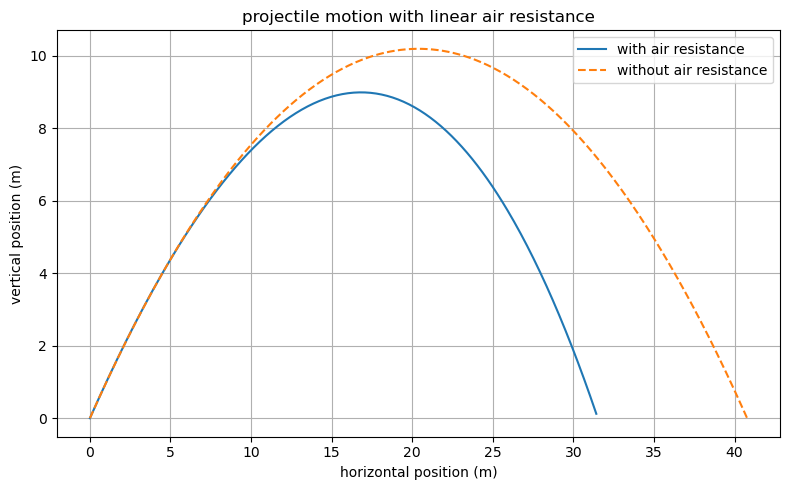

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

# ====== physical parameters ======

g = 9.81                          # gravitational acceleration (m/s^2)
v0 = 20                           # initial velocity (m/s)
k = 0.15                          # linear drag coefficient (1/s)         
angle_deg = 45                    # launch angle (degrees)
theta = np.radians(angle_deg)    
dt = 0.01                         # time step (s) 
t = 0.0 

# ====== initial conditions ======

vx = v0 * np.cos(theta)
vy = v0 * np.sin(theta)

x = 0.0
y = 0.0

x_values = [x]
y_values = [y]

# === numerical simulation using Euler's method ===

while y >= 0 :
    # calculate acceleration from the current velocity 
    ax = -k * vx
    ay = -g -k * vy 
    # update position
    x_new = x + vx * dt 
    y_new = y + vy * dt
    # interpolate to estimate the landing position and time 
    if y_new < 0 :
        f = y / (y - y_new)
        x_impact = x + f * (x_new - x )
        t_impact = t + f *dt 
        range_numerical = x_impact
        flight_time_numerical = t_impact
        break
    # update velocity
    vx_new = vx + ax *dt
    vy_new = vy + ay * dt
    # update position and velocity
    x = x_new
    y = y_new
    vx = vx_new
    vy = vy_new
    # store trajectory 
    x_values.append(x)
    y_values.append(y
                   ) 
    t += dt

# === analytical solution without air resistance ===

flight_time_exact = 2 * v0 * np.sin(theta) / g
range_exact = v0 ** 2 * np.sin(2*theta) / g 

# results
results = pd.DataFrame({"quantity" : ["flight time (s)","range(m)"] , 
                        "with air resistance" : [flight_time_numerical , range_numerical] ,
                        "without air resistance" : [flight_time_exact , range_exact] })
print(results.to_string(index = False))

# ====== analytical trajectory without air resistant ======

x_exact = np.linspace(0 , range_exact , 500)
y_exact = ( x_exact * np.tan(theta) - (g * x_exact**2)/(2* v0**2 * np.cos(theta)**2) )

# ====== visualization ====== 

plt.figure(figsize = (8,5))
plt.plot( x_values , y_values , label='with air resistance')
plt.plot(x_exact , y_exact , '--', label = 'without air resistance' )
plt.title('projectile motion with linear air resistance')
plt.xlabel('horizontal position (m)')
plt.ylabel('vertical position (m)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()   
